# Lensless Demo

In [1]:
from pathlib import Path
import subprocess
import os
import sys
import zipfile

### Checking if demo is located in repo root. In other case cloning the repo

In [2]:
REPO_URL = "https://github.com/m-dumbduck/lensless.git"
REPO_FOLDER = "lensless"
EXPECTED_FILE = ".is_repo"
EXPECTED_TEXT_IN_FILE = "lensless"

def check_indicator(path):
    indicator = Path.cwd() / path / EXPECTED_FILE
    if not indicator.is_file():
        return False
    return indicator.read_text(encoding="utf-8").strip() == EXPECTED_TEXT_IN_FILE

In [3]:
if not check_indicator('.') and not check_indicator(REPO_FOLDER):
    subprocess.run(["git", "clone", REPO_URL, REPO_FOLDER], check=True)
if check_indicator(REPO_FOLDER):
    os.chdir(REPO_FOLDER)

#### Installing dependencies

In [4]:
!pip install -r requirements.txt -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [5]:
import matplotlib.pyplot as plt
from PIL import Image

## Demonstration

You can paste any link to `YOUR_ARCHIVE_LINK`. The link must contain archive of CustomDir structure. The default link is provided.

**CustomDir structure**

```bash
NameOfTheDirectoryWithData
├── lensless
│   ├── ImageID1.png
│   ├── ImageID2.png
│   .
│   .
│   .
│   └── ImageIDn.png
├── masks
│   ├── ImageID1.npy
│   ├── ImageID2.npy
│   .
│   .
│   .
│   └── ImageIDn.npy
└── lensed # ground truth original image, may not exist
    ├── ImageID1.png
    ├── ImageID2.png
    .
    .
    .
    └── ImageIDn.png
```

In [6]:
YOUR_ARCHIVE_LINK = "https://drive.google.com/file/d/1LZaJJkYHRzMx00-zQgTB3PplB41Uq8LV/view?usp=sharing"

### Download and unpack archive

In [7]:
# --------------------------------------------
# You can provide your own custom DATA_DIR and ARCHIVE_PATH

DATA_DIR = Path("data/demo_input")
ARCHIVE_PATH = Path("data/demo_input.zip")

# -------------------------------------------

ARCHIVE_PATH.parent.mkdir(parents=True, exist_ok=True)
subprocess.run(["gdown", "--fuzzy", YOUR_ARCHIVE_LINK, "-O", ARCHIVE_PATH], check=True)

DATA_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ARCHIVE_PATH) as zf:
    zf.extractall(DATA_DIR)

if not (DATA_DIR / "lensless").exists():
    DATA_DIR = [p for p in DATA_DIR.iterdir() if p.is_dir()][0]

print("Dataset unzipped at:", DATA_DIR)
print("Contents:", [p.name for p in DATA_DIR.iterdir()])


Downloading...
From (original): https://drive.google.com/uc?id=1LZaJJkYHRzMx00-zQgTB3PplB41Uq8LV
From (redirected): https://drive.google.com/uc?id=1LZaJJkYHRzMx00-zQgTB3PplB41Uq8LV&confirm=t&uuid=2224a688-7154-4c3c-9aa4-a1f1955495a0
To: /Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/data/demo_input.zip
 89%|████████▉ | 30.9M/34.7M [00:01<00:00, 28.0MB/s]

Dataset unzipped at: data/demo_input/lensless-example
Contents: ['lensless', 'lensed', 'masks']


100%|██████████| 34.7M/34.7M [00:01<00:00, 20.7MB/s]


### Run inference

In [8]:
# --------------------------------------------
# You can choose any of the following models

MODEL = "le_admm_pre_post"
MODEL_REGISTRY = {
    "admm": None,
    "unrolled_admm": "ldiujes/unrolled-admm",
    "le_admm_pre": "ldiujes/le-admm-pre",
    "le_admm_post": "ldiujes/le-admm-post",
    "le_admm_pre_post": "ldiujes/le-admm-pre-post",
}

# --------------------------------------------

In [9]:
SAVE_NAME = "demo"

args = [
    sys.executable, "inference.py",
    "datasets=custom_dir",
    f"datasets.test.data_dir={DATA_DIR}",
    f"model={MODEL}",
    f"inferencer.save_path={SAVE_NAME}",
]

weights = MODEL_REGISTRY[MODEL]
if weights is None:                         # admm: грузить нечего
    args += [
        "inferencer.skip_model_load=true",
        "inferencer.from_pretrained=null",
        "inferencer.from_pretrained_type=null",
    ]
else:                                       # остальные: веса с HF
    args += [
        f"inferencer.from_pretrained={weights}",
        "inferencer.from_pretrained_type=hf",
    ]

subprocess.run(args, check=True)

PRED_DIR = Path("data/saved") / SAVE_NAME / "test"
print("Reconstructions saved to:", PRED_DIR)

Overriding save directory '/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/inference_logs/inference'...
Logging git commit and patch...
HTTP Request: GET https://huggingface.co/api/models/ldiujes/le-admm-pre-post/revision/main "HTTP/1.1 200 OK"
LeADMM(
  (preprocessor): DRUNet(
    (in_conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (downscaling_sequence): ModuleList(
      (0): ModuleList(
        (0): ResidualBlockStack(
          (net): Sequential(
            (0): ResidualBlock(
              (net): Sequential(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                (1): ReLU()
                (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              )
            )
            (1): ResidualBlock(
              (net): Sequential(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                (1): ReLU()
                (2): Conv2d(32, 32, k

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 9500.12it/s]



Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Loading model weights from: /Users/maksim/.cache/huggingface/hub/models--ldiujes--le-admm-pre-post/snapshots/969c9ce7bafaeb57fe4f0488bb4f638cf65a0e3f/model.safetensors ...


test: 100%|██████████| 50/50 [02:33<00:00,  3.06s/it]


    test_MSEMetric : 0.025925033427774906
    test_LPIPSMetric: 0.5780196529626846
    test_PeakSignalNoiseRatioMetric: 16.556347274780272
    test_StructuralSimilarityIndexMeasureMetric: 0.4085730384290218
Reconstructions saved to: data/saved/demo/test


### Examples

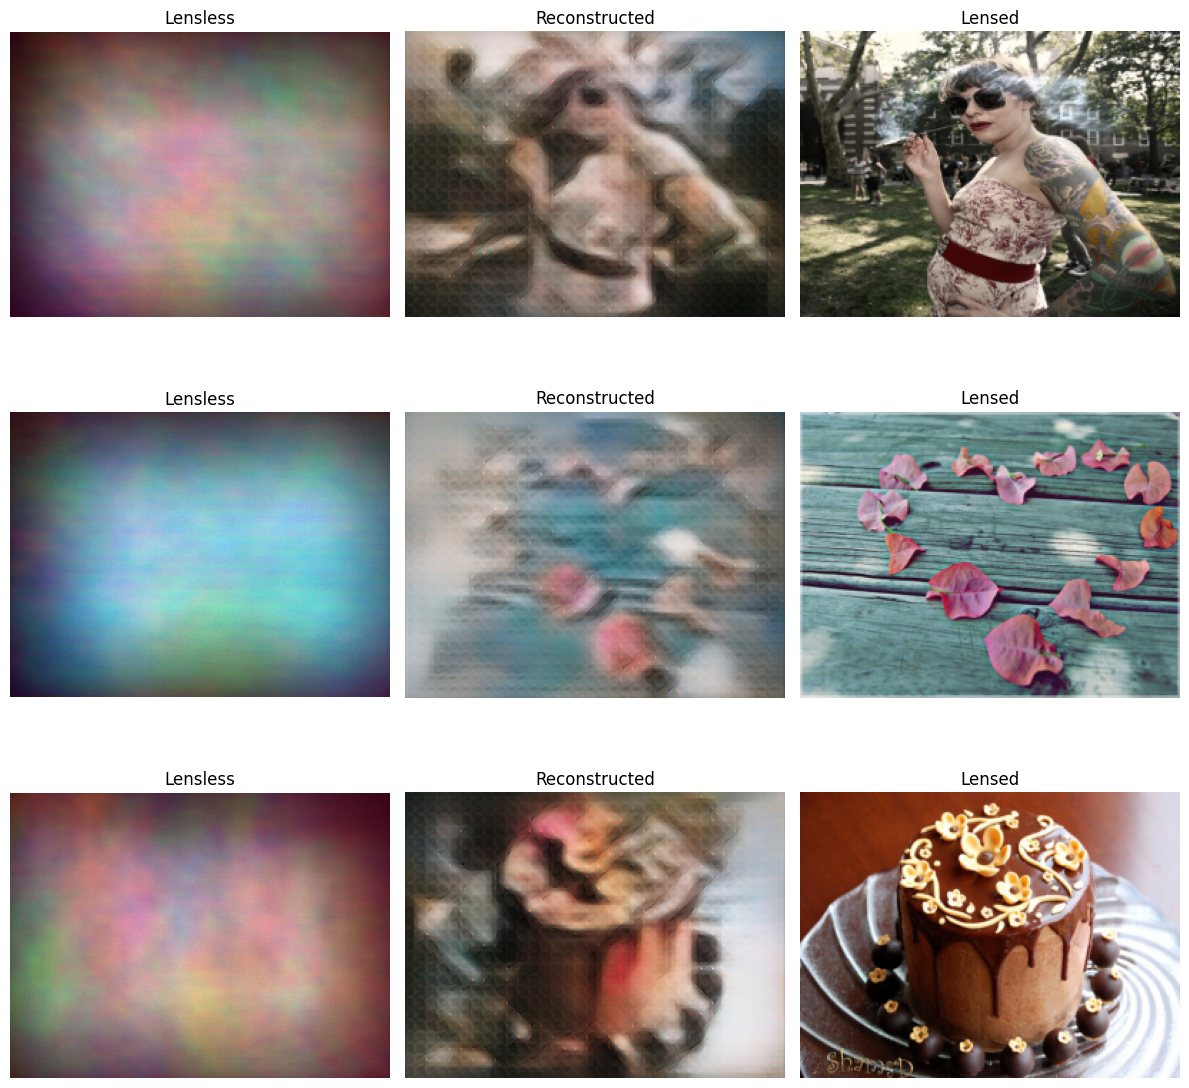

In [10]:
from src.lensless_helpers.preprocessor import get_dataset_object, get_roi

# --------------------
# You can adjust number of images to show

N_SHOW = 3

# --------------------

lensless_dir = DATA_DIR / "lensless"
lensed_dir = DATA_DIR / "lensed"
has_lensed = lensed_dir.is_dir() and any(lensed_dir.glob("*.png"))

pred_paths = sorted(PRED_DIR.glob("*.png"))[:N_SHOW]
n_cols = 3 if has_lensed else 2

fig, axes = plt.subplots(len(pred_paths), n_cols, figsize=(4 * n_cols, 4 * len(pred_paths)))
if len(pred_paths) == 1:
    axes = axes[None, :]

for row, pred_path in enumerate(pred_paths):
    image_id = pred_path.stem
    axes[row, 0].imshow(Image.open(lensless_dir / f"{image_id}.png"))
    axes[row, 0].set_title("Lensless")
    axes[row, 1].imshow(Image.open(pred_path))
    axes[row, 1].set_title("Reconstructed")
    if has_lensed:
        lensed, _, _ = get_dataset_object(
            Image.open(lensed_dir / f"{image_id}.png"),
            Image.open(lensless_dir / f"{image_id}.png"),
            None
        )
        lensed = get_roi(lensed.permute(2, 0, 1)).permute(1, 2, 0).numpy()
        axes[row, 2].imshow(lensed)
        axes[row, 2].set_title("Lensed")

    for c in range(n_cols):
        axes[row, c].axis("off")

plt.tight_layout()
plt.show()


### Metrics

Final metrics calculation

In [11]:
if has_lensed:
    res = subprocess.run(
        [sys.executable, "calculate_metrics.py", "--gt", lensed_dir, "--pred", PRED_DIR],
        capture_output=True, text=True,
    )
    print(res.stdout)
else:
    print("No 'lensed/' folder -> ground truth unavailable, metrics skipped")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Metrics over 50 image(s):
    MSEMetric: 0.025926232589408755
    LPIPSMetric: 0.578259813785553
    PeakSignalNoiseRatioMetric: 16.55607913970947
    StructuralSimilarityIndexMeasureMetric: 0.4082851029932499

